In [37]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/access_electricity.csv')
display(df.head())

,Country Name,Country Code,Series Name,Series Code,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],Continent
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,69.1,67.2595520019531,89.5,71.5,84.1371383666992,Asia
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe
2,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,98.7646604654583,99.1349868774414,99.2343444824219,99.3367080688477,99.439567565918,Africa
3,American Samoa,ASM,Access to electricity (% of population),EG.ELC.ACCS.ZS,..,..,..,..,..,Oceania
4,Andorra,AND,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe


## Esplorazione iniziale: numero di dati (righe e colonne), tipo di dati (commento).



In [38]:
print("Numero di dati e tipo di dati:", df.shape)
df.info()

Numero di dati e tipo di dati: (242, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   242 non-null    object
 1   Country Code   242 non-null    object
 2   Series Name    242 non-null    object
 3   Series Code    242 non-null    object
 4   2012 [YR2012]  242 non-null    object
 5   2013 [YR2013]  242 non-null    object
 6   2014 [YR2014]  242 non-null    object
 7   2015 [YR2015]  242 non-null    object
 8   2016 [YR2016]  242 non-null    object
 9   Continent      228 non-null    object
dtypes: object(10)
memory usage: 19.0+ KB


## 4 selezioni dei dati motivate (commento per ciascuna), 2 delle quali usanto .loc[] e .iloc[].

In [39]:
df_africa = df[df['Continent'] == 'Africa'].copy()
display(df_africa.head())

,Country Name,Country Code,Series Name,Series Code,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],Continent
2,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,98.7646604654583,99.1349868774414,99.2343444824219,99.3367080688477,99.439567565918,Africa
5,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,35.821964263916,36.9904899597168,32,42,40.5206069946289,Africa
21,Benin,BEN,Access to electricity (% of population),EG.ELC.ACCS.ZS,38.4,37.2992057800293,34.1,40.0334777832031,41.4026145935059,Africa
26,Botswana,BWA,Access to electricity (% of population),EG.ELC.ACCS.ZS,52.0633392333984,54.2134704589844,56.3696098327637,58.528751373291,60.6883964538574,Africa
31,Burkina Faso,BFA,Access to electricity (% of population),EG.ELC.ACCS.ZS,16.3997077941895,17.0848274230957,19.2,18.4700813293457,19.1647129058838,Africa


* Seleziono le colonne per ciascun paese europeo in base all'accesso all'elettricità nel 2016
* Ne prendo le prime 5
* Uso .loc


In [40]:
df_europe_2016 = df.loc[df['Continent'] == 'Europe', ['Country Name', '2016 [YR2016]']].copy()
display(df_europe_2016.head())

,Country Name,2016 [YR2016]
1,Albania,100
4,Andorra,100
12,Austria,100
18,Belarus,100
19,Belgium,100


Seleziono le primr 10 righe con .iloc per far vedere come funziona la selezione usando il numero di indice e di colonna



In [41]:
df_iloc_selection = df.iloc[0:11, 5:8].copy()
display(df_iloc_selection.head())

,2013 [YR2013],2014 [YR2014],2015 [YR2015]
0,67.2595520019531,89.5,71.5
1,100,100,100
2,99.1349868774414,99.2343444824219,99.3367080688477
3,..,..,..
4,100,100,100


Seleziono le righe dove nella colonna dell'anno 2015 hanno valori più grandi di 90 accessi


In [42]:
df_high_access_2015 = df[pd.to_numeric(df['2015 [YR2015]'], errors='coerce') > 90].copy()
display(df_high_access_2015.head())

,Country Name,Country Code,Series Name,Series Code,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],Continent
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe
2,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,98.7646604654583,99.1349868774414,99.2343444824219,99.3367080688477,99.439567565918,Africa
4,Andorra,AND,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe
6,Antigua and Barbuda,ATG,Access to electricity (% of population),EG.ELC.ACCS.ZS,95.2546920776367,95.773551940918,96.2984161376953,96.8262939453125,97.3546676635742,North America
8,Argentina,ARG,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.5844116210938,99.8371276855469,99.9592437744141,99.9952087402344,100,South America


##  2 riodinamenti (1 ascendente e 1 discendente) di due variabili a scelta motivate (commento per ciascuno)

Ordino gli accessi dell'anno 2015 dal più grande al più piccolo e ne stampo le prime 5 usando head(), per vedere quali paesi hanno avuto accesso all'elettricità maggiormente nel 2015


In [43]:
df_high_access_2015_asc = df_high_access_2015.sort_values(by='2015 [YR2015]', ascending=True)
display(df_high_access_2015_asc.head())

,Country Name,Country Code,Series Name,Series Code,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],Continent
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe
159,New Caledonia,NCL,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Oceania
158,Netherlands,NLD,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe
149,Monaco,MCO,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe
148,Moldova,MDA,Access to electricity (% of population),EG.ELC.ACCS.ZS,100,100,100,100,100,Europe


Converto in int i valori della colonna dell'anno 2016, del continente africano, elimino le righe vuote,
e ordino le righe in maniera decrescente


In [44]:
df_africa['2016 [YR2016]'] = pd.to_numeric(df_africa['2016 [YR2016]'], errors='coerce')
df_africa_cleaned = df_africa.dropna(subset=['2016 [YR2016]']).copy()

df_africa_desc = df_africa_cleaned.sort_values(by='2016 [YR2016]', ascending=False)
display(df_africa_desc.head())

,Country Name,Country Code,Series Name,Series Code,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],Continent
61,"Egypt, Arab Rep.",EGY,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.7,99.9950942993164,99.8,100,100.000000,Africa
220,Tunisia,TUN,Access to electricity (% of population),EG.ELC.ACCS.ZS,99.5,99.7,99.8,100,100.000000,Africa
189,Seychelles,SYC,Access to electricity (% of population),EG.ELC.ACCS.ZS,98.4092712402344,98,99.2988891601563,99.6783218383789,100.000000,Africa
152,Morocco,MAR,Access to electricity (% of population),EG.ELC.ACCS.ZS,95.1765670776367,97.3740081787109,91.6,99.5860137939453,100.000000,Africa
2,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,98.7646604654583,99.1349868774414,99.2343444824219,99.3367080688477,99.439568,Africa


## 1 nuova colonna creata usando apply e lambda (commento).


Aggiungo una colonna in più dove riga per riga fa la media per tutti gli anni, crendo prima una lista con le colonne dei campi degli anni, mettendo year nel range degli anni che ci sono (dal 2012 al 2017)

In [45]:
year_columns = [f'{year} [YR{year}]' for year in range(2012, 2017)]
# Convert year columns to numeric, coercing errors to NaN
for col in year_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['media tra tutti gli anni'] = df[year_columns].mean(axis=1)
display(df.head())

,Country Name,Country Code,Series Name,Series Code,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],Continent,media tra tutti gli anni
0,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,69.10000,67.259552,89.500000,71.500000,84.137138,Asia,76.299338
1,Albania,ALB,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.00000,100.000000,100.000000,100.000000,100.000000,Europe,100.000000
2,Algeria,DZA,Access to electricity (% of population),EG.ELC.ACCS.ZS,98.76466,99.134987,99.234344,99.336708,99.439568,Africa,99.182053
3,American Samoa,ASM,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,Oceania,NaN
4,Andorra,AND,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.00000,100.000000,100.000000,100.000000,100.000000,Europe,100.000000


## 5 grafici comprensivi di titolo, labels e interpretazione (commento per ciascuno) di cui almeno 1 boxplot, 1 istogramma e 1 scatterplot usando sia Matplotlib che Seaborn.

importo matplotlib e seaborn

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

Questo grafico mostra la distribuzione dell'accesso medio all'elettricità (tra il 2012 e il 2016) tra tutti i paesi presenti nel dataset. L'ho colorato in verde acqua




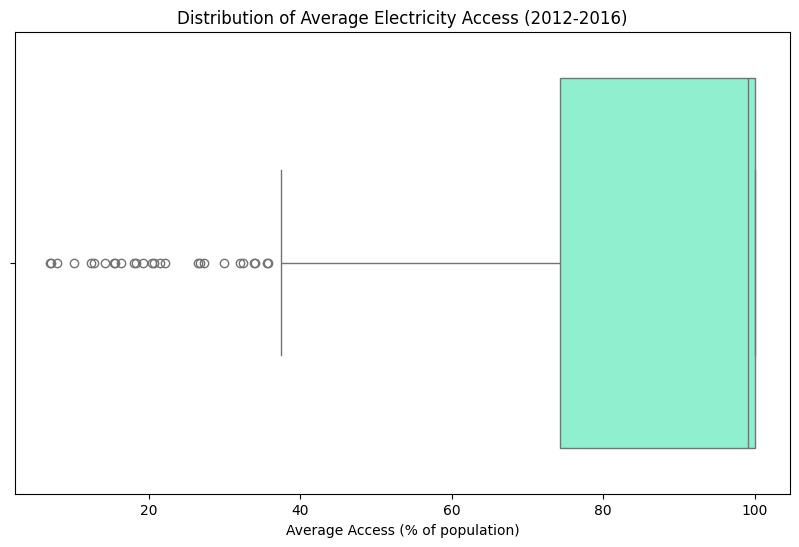

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['media tra tutti gli anni'], color='aquamarine') # Verde acqua
plt.title('Distribution of Average Electricity Access (2012-2016)')
plt.xlabel('Average Access (% of population)')
plt.show()

Questo istogramma mostra la distribuzione dell'accesso medio all'elettricità (tra il 2012 e il 2016), suddivisa per continente. Possiamo osservare come la distribuzione vari tra i diversi continenti, con alcuni che mostrano un accesso prevalentemente alto e altri con una maggiore concentrazione di paesi con accesso inferiore.

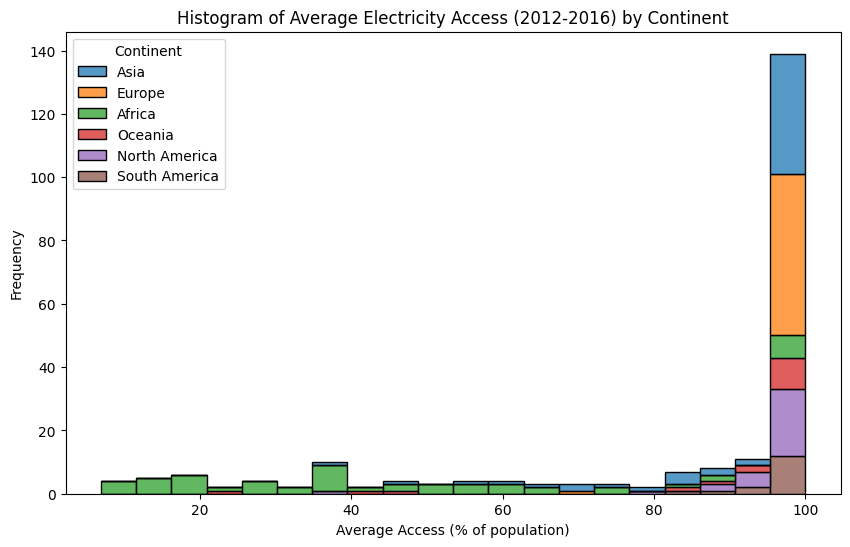

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='media tra tutti gli anni', hue='Continent', multiple='stack', bins=20, edgecolor='black')
plt.title('Histogram of Average Electricity Access (2012-2016) by Continent')
plt.xlabel('Average Access (% of population)')
plt.ylabel('Frequency')
plt.show()

Questo scatterplot mostra la relazione tra l'accesso all'elettricità nel 2012 e nel 2016, con colori diversi in base al continente. Si può osservare una forte correlazione positiva, indicando che i paesi con un accesso elevato nel 2012 tendono ad avere un accesso elevato anche nel 2016.

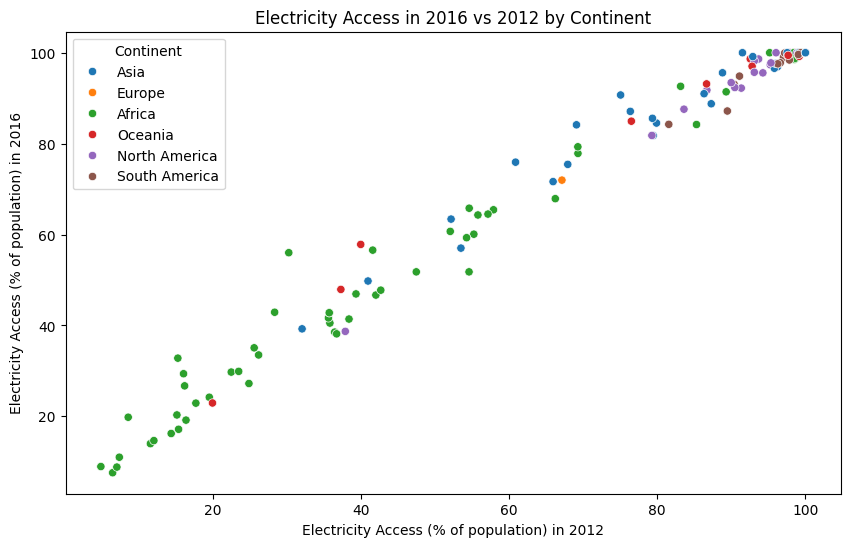

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['2012 [YR2012]'], y=df['2016 [YR2016]'], hue='Continent', data=df)
plt.title('Electricity Access in 2016 vs 2012 by Continent')
plt.xlabel('Electricity Access (% of population) in 2012')
plt.ylabel('Electricity Access (% of population) in 2016')
plt.show()

Questo scatterplot mostra la relazione tra l'accesso all'elettricità nel 2012 e nel 2016 specificamente per i paesi africani.  Per identificare se ci sono paesi africani che hanno fatto progressi significativi nell'aumentare l'accesso all'elettricità tra il 2012 e il 2016.

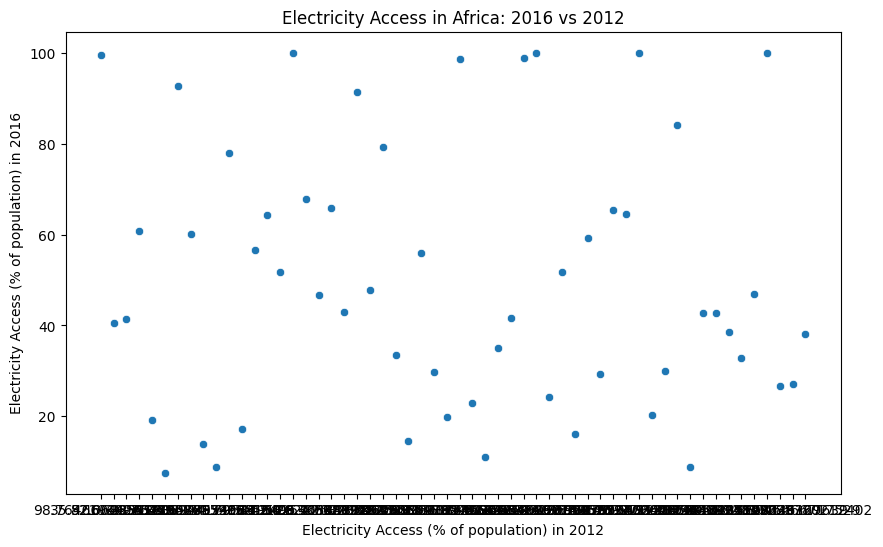

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_africa_cleaned['2012 [YR2012]'], y=df_africa_cleaned['2016 [YR2016]'])
plt.title('Electricity Access in Africa: 2016 vs 2012')
plt.xlabel('Electricity Access (% of population) in 2012')
plt.ylabel('Electricity Access (% of population) in 2016')
plt.show()

Questo istogramma mostra la distribuzione della percentuale di popolazione con accesso all'elettricità nei paesi africani nel 2016. L'asse orizzontale rappresenta le percentuali di accesso all'elettricità, mentre l'asse verticale indica il numero di paesi per ciascun intervallo di percentuale. I colori diversi per ogni barra aiutano a distinguere visivamente gli intervalli.

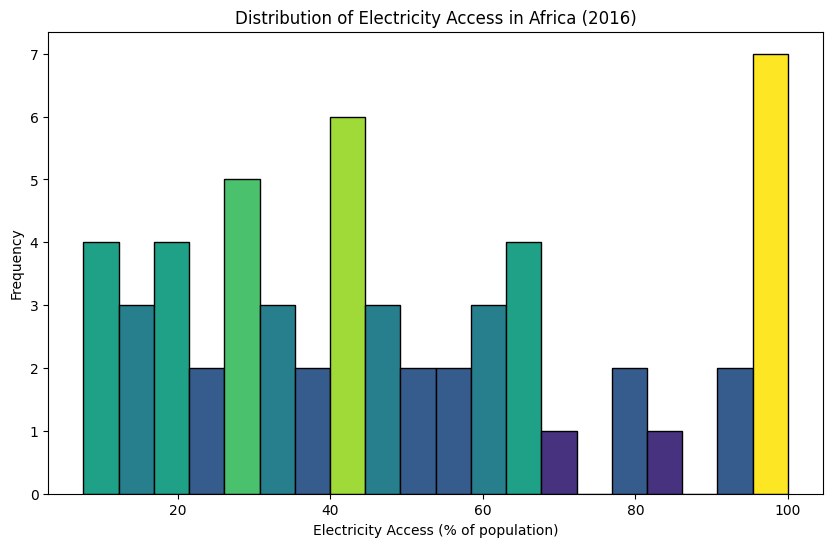

In [51]:
plt.figure(figsize=(10, 6))
# Get the counts and bins for the histogram
counts, bins, patches = plt.hist(df_africa_cleaned['2016 [YR2016]'].dropna(), bins=20, edgecolor='black')

# Assign a different color to each bar
colors = plt.cm.viridis(counts / max(counts)) # Using a colormap based on frequency
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.title('Distribution of Electricity Access in Africa (2016)')
plt.xlabel('Electricity Access (% of population)')
plt.ylabel('Frequency')
plt.show()

## Commento conclusivo che comprenda una riassunto di ciò che si è scoperto ed futuri sviluppi.

Questa analisi preliminare sui dati di accesso all'elettricità ha rivelato diverse tendenze interessanti tra il 2012 e il 2016. Abbiamo osservato che:

*   Esistono differenze significative nell'accesso all'elettricità tra i vari continenti, con alcuni che presentano un accesso medio più elevato di altri.
*   C'è una forte correlazione positiva tra l'accesso all'elettricità nel 2012 e nel 2016, suggerendo che i paesi con un accesso già elevato tendono a mantenerlo o migliorarlo ulteriormente.
*   Focalizzandoci sull'Africa, abbiamo potuto osservare la distribuzione dell'accesso e identificare paesi con diversi livelli di progresso.

**Futuri Sviluppi:**

Per approfondire questa analisi, si potrebbero considerare i seguenti sviluppi:

*   **Includere più anni**
*   **Esplorare altri fattori**
*   **Focus su paesi specifici**